# MLP : Résultats et observations sur le dataset

In [1]:
import os
import sys
import io
import ctypes
import json
from ctypes import *
import numpy as np
import numpy.ctypeslib
from PIL import Image

from utils import *
from dataset import *

from lib_loader import load_my_lib

seed = 42

2024-07-23 23:37:14.908557: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-23 23:37:15.197604: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-23 23:37:15.836527: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Dataset

X_train shape: (14763, 48, 48, 3)
y_train shape: (14763, 3)
X_test shape: (3700, 48, 48, 3)
y_test shape: (3700, 3)


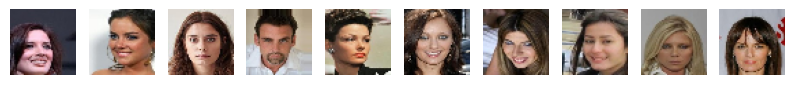

In [2]:
# Charger le dataset
image_size = 48  # Taille des images
dataset_path = '../dataset_upgrade'
X_train, y_train, X_test, y_test = load_dataset(dataset_path, image_size)
X_train, y_train = shuffle_dataset(X_train, y_train)

X_test, y_test = shuffle_dataset(X_test, y_test)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

display_images(X_train, 10)

## Chargement de la librairie

In [2]:
path = "../my_lib/target/release/deps/libmy_lib.so"

lib = load_my_lib(path)

### Preprocessing des données

In [4]:
# Normaliser les données
X_train_normalized, X_test_normalized = z_normalize(X_train, X_test)

# Aplatir les images pour MLP
X_train_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)
X_test_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)

input_dim = X_train_flat.shape[1]
output_dim = y_train.shape[1]

# Modèle Linéaire

Le modèle linéaire, en tant que modèle simple, sert de référence initiale. Il nous permet d'établir un score de base à dépasser, idéalement supérieur à 0,33.

In [ ]:
# Créer un modèle linéaire
n_features = X_train.shape[1] * X_train.shape[2] * X_train.shape[3]
n_classes = y_train.shape[1]
model_ptr = lib.create_MyLinearModel(n_features, n_classes, seed)

# Entraîner le modèle
learning_rate = 0.001
epochs = 10000
is_classification = True

lib.train_MyLinearModel(
    model_ptr,
    X_train.flatten().astype(np.double),
    y_train.flatten().astype(np.double),
    X_test.flatten().astype(np.double),
    y_test.flatten().astype(np.double),
    X_train.shape[0], X_test.shape[0],
    n_features, n_classes,
    learning_rate, epochs,
    int(is_classification)
)

lib.destroy_MyLinearModel(model_ptr)

Training starting...
Epoch 0: Train Loss: 3.0643, Test Loss: 2.4941, Train Acc: 40.4%, Test Acc: 39.0%
Epoch 1: Train Loss: 3.0083, Test Loss: 3.0679, Train Acc: 41.7%, Test Acc: 36.8%
Epoch 2: Train Loss: 2.9941, Test Loss: 3.0982, Train Acc: 42.1%, Test Acc: 38.6%
Epoch 3: Train Loss: 2.9687, Test Loss: 3.2724, Train Acc: 42.6%, Test Acc: 38.1%
Epoch 4: Train Loss: 2.9679, Test Loss: 3.0605, Train Acc: 42.2%, Test Acc: 38.6%
Epoch 5: Train Loss: 2.9656, Test Loss: 3.0809, Train Acc: 42.0%, Test Acc: 38.7%
Epoch 6: Train Loss: 2.9405, Test Loss: 2.7956, Train Acc: 43.0%, Test Acc: 38.8%
Epoch 7: Train Loss: 2.9203, Test Loss: 3.5097, Train Acc: 43.3%, Test Acc: 39.4%
Epoch 8: Train Loss: 2.9269, Test Loss: 3.9100, Train Acc: 43.7%, Test Acc: 37.1%
Epoch 9: Train Loss: 2.9392, Test Loss: 3.1492, Train Acc: 43.4%, Test Acc: 37.5%
Epoch 10: Train Loss: 2.8971, Test Loss: 3.3773, Train Acc: 43.6%, Test Acc: 38.8%
Epoch 11: Train Loss: 2.9074, Test Loss: 3.5797, Train Acc: 44.0%, Test Acc:

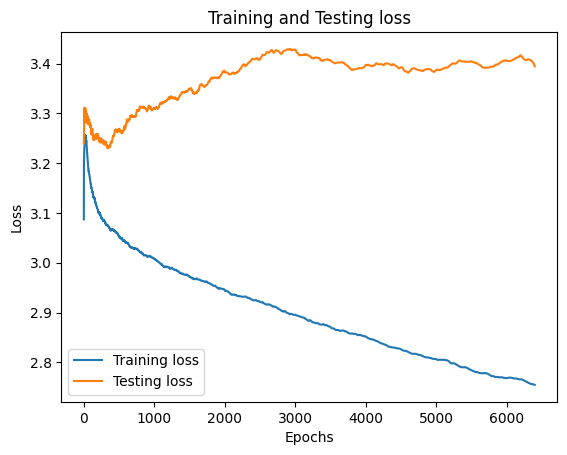

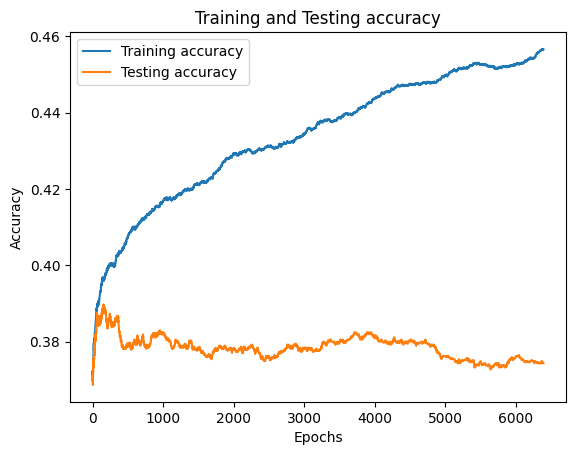

In [8]:
path = '/home/bao/GranolaGPT/PA_models/LinearModel/LINEAR/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [15]:
print(min(history["train_losses"]))
print(min(history["test_losses"]))

print(max(history["train_accuracies"]))
print(max(history["test_accuracies"]))

2.754683887471777
3.2301811169102614
0.4566822461559304
0.38972972972972975


# MLP

## 0. Preprocessing des données 

Pour le MLP, nous avons implémenté la fonction d'activation tanh. Comme nous l'avons vu en cours, cette fonction étant bornée entre -1 et 1, il est préférable de normaliser les données en utilisant la méthode de Z normalization.

In [ ]:
dataset_path = '../dataset_upgrade'
X_train, y_train, X_test, y_test = load_dataset(dataset_path, image_size)
X_train, y_train = shuffle_dataset(X_train, y_train)
X_test, y_test = shuffle_dataset(X_test, y_test, seed)

X_train, X_test = z_normalize(X_train, X_test)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

input_dim = X_train_flat.shape[1]
output_dim = y_train.shape[1]

## 1. Structure simple

Commençons très simplement en ajoutant une seule couche cachée à 8 neurones afin de se faire une première idée de l'impact d'une couche.

Notre premier objectif était de comprendre l'impact du learning rate sur l'entraînement. Nous avons commencé avec un learning rate très petit (0.0001).

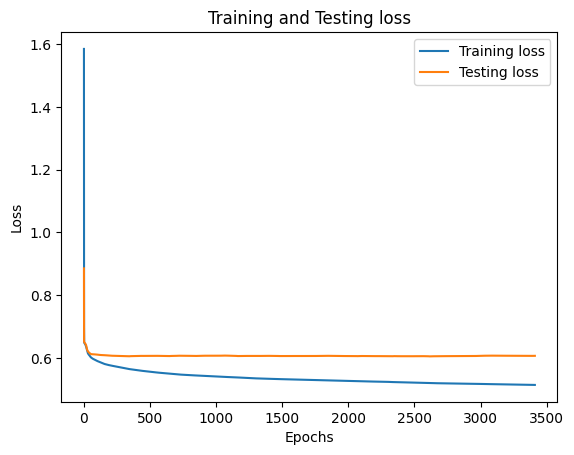

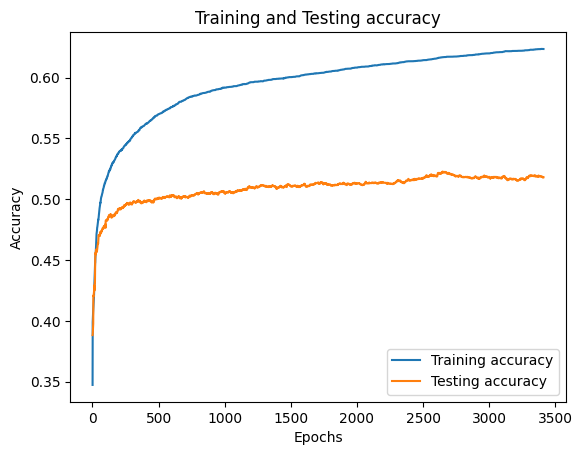

In [16]:
# layers = np.array([input_dim, 8, output_dim], dtype=np.int32)
# num_layers = len(layers)

# mlp = lib.create_MyMLP(layers, num_layers, seed)

# lib.summary_MyMLP(mlp)

# alpha = 0.0001
# epochs = 10000
# is_classification = True

# lib.train_MyMLP(
#     mlp,
#     X_train_flat,
#     y_train,
#     X_test_flat,
#     y_test,
#     X_train_flat.shape[0],
#     X_test_flat.shape[0],
#     X_train_flat.shape[1],
#     y_train.shape[1],
#     alpha,
#     epochs,
#     is_classification
# )

path = '../PA_models/MLP_models/lr_00001_6912_8_3/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [17]:
print(min(history["train_losses"]))
print(min(history["test_losses"]))

print(max(history["train_accuracies"]))
print(max(history["test_accuracies"]))

0.5136486944868572
0.6044779062371565
0.6235182550972025
0.5227027027027027


Nous observons un comportement typique des courbes d'apprentissage. Les courbes de précision (accuracy) se séparent autour de 0,5, indiquant un surapprentissage (overfitting) du modèle. Malgré des scores relativement bas, il est important de noter que ce modèle surpasse déjà la régression linéaire. On remarque tout de même que les courbes semblent encore augmenter, suggérant que le modèle ne s'est peut être passez entraîné.

Ce premier résultat semble nous encourager à augmenter le taux d'apprentissage. Testons donc ce même modèle avec un taux d'apprentissage de 0,01 pour observer les effets.

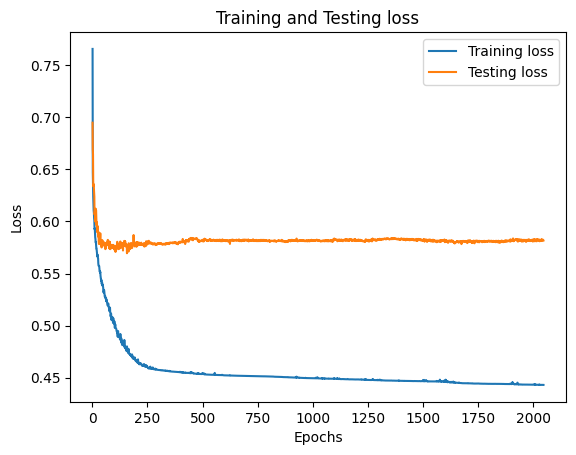

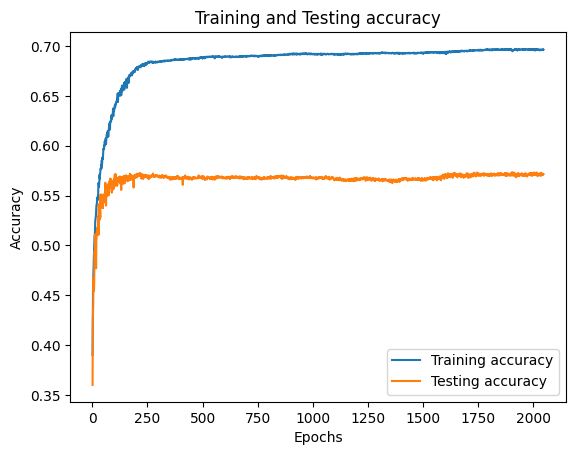

In [18]:
# layers = np.array([input_dim, 8, output_dim], dtype=np.int32)
# num_layers = len(layers)

# mlp = lib.create_MyMLP(layers, num_layers, seed)

# lib.summary_MyMLP(mlp)

# alpha = 0.01
# epochs = 10000
# is_classification = True

# lib.train_MyMLP(
#     mlp,
#     X_train_flat,
#     y_train,
#     X_test_flat,
#     y_test,
#     X_train_flat.shape[0],
#     X_test_flat.shape[0],
#     X_train_flat.shape[1],
#     y_train.shape[1],
#     alpha,
#     epochs,
#     is_classification
# )

path = '../PA_models/MLP_models/lr_001_6912_8_3/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [19]:
print(min(history["train_losses"]))
print(min(history["test_losses"]))

print(max(history["train_accuracies"]))
print(max(history["test_accuracies"]))

0.4431046826067959
0.5694563586865986
0.6972160130054866
0.5735135135135135


Avec un taux d'apprentissage plus élevé, nous observons que le modèle atteint son plafond de performance beaucoup plus rapidement. Bien que les courbes d'apprentissage soient moins stables et présentent davantage de fluctuations, la tendance générale de la courbe reste discernable. Cela suggère que, malgré l'instabilité accrue, le modèle converge vers sa performance maximale à un rythme accéléré. Cette observation souligne l'impact significatif du taux d'apprentissage sur la vitesse de convergence, même si elle entraîne une variabilité plus prononcée dans le processus d'entraînement.

#### Ajoutons des neurones

D'après l'analyse des courbes précédentes, nous pouvons supposer qu'ajouter des neurones à la couche cachée risque d'accentuer l'effet de surapprentissage (overfitting). Cependant, il est important de vérifier cette hypothèse. Nous allons donc tester cette théorie en augmentant la taille de la couche cachée à 32 neurones.

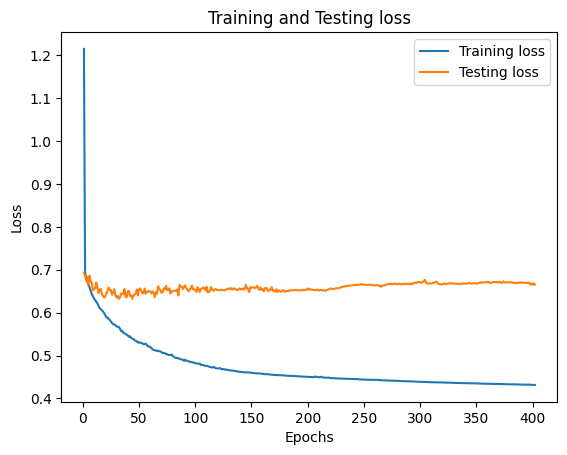

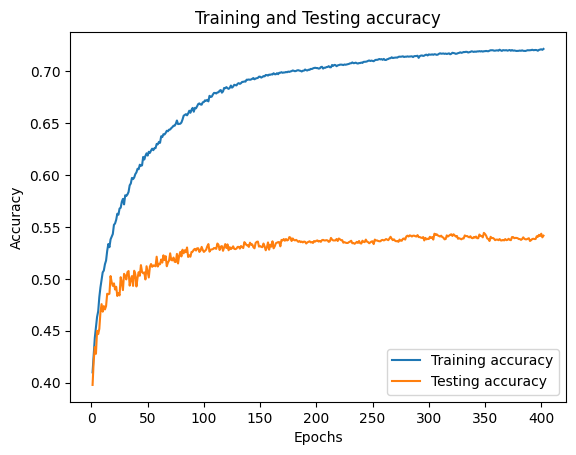

In [55]:
layers = np.array([input_dim, 32, output_dim], dtype=np.int32)
num_layers = len(layers)

mlp = lib.create_MyMLP(layers, num_layers, seed)

lib.summary_MyMLP(mlp)

alpha = 0.01
epochs = 10000
is_classification = True

lib.train_MyMLP(
    mlp,
    X_train_flat,
    y_train,
    X_test_flat,
    y_test,
    X_train_flat.shape[0],
    X_test_flat.shape[0],
    X_train_flat.shape[1],
    y_train.shape[1],
    alpha,
    epochs,
    is_classification
)

path = '../PA_models/MLP_models/lr_001_6912_32_3/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [56]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.54


La perte d'entraînement diminue régulièrement jusqu'à atteindre un niveau bas, tandis que la perte de test diminue initialement avant de se stabiliser à un niveau plus élevé. L'accuracy d'entraînement augmente pour atteindre environ 70%, alors que l'accuracy de test se stabilise autour de 55%. Ces observations suggèrent un surapprentissage (overfitting), comme l'indique l'écart entre les courbes d'entraînement et de test. De plus, les scores du modèle sont nettement inférieurs à ceux de l'entraînement, confirmant la présence de ce phénomène.

**À partir de ces premiers résultats, nous tirons les conclusions suivantes :**

- Le surapprentissage (overfitting) semble être la principale tendance observée.
- Il est préférable de ne pas dépasser 32 neurones par couche.
- Un taux d'apprentissage de 0,01 semble être un bon point de départ.


## 2. Plus de couches

Maintenant que nous avons une première intuitions de l'impact d'une seule couche cachée, la prochaine étape logique est de rajouter des couches pour observer les résultats.

Testons le modèle précédent en y ajoutant une couche de 4 neurones :

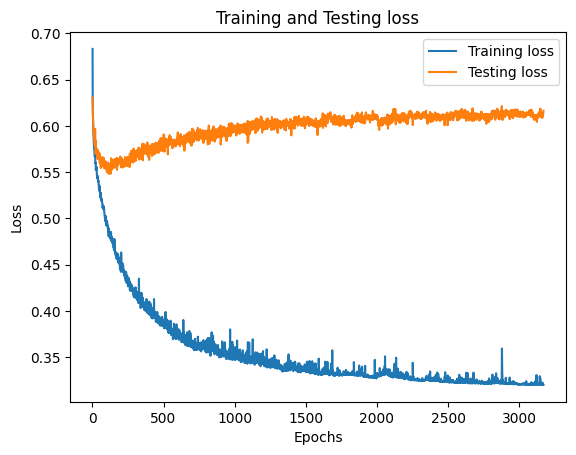

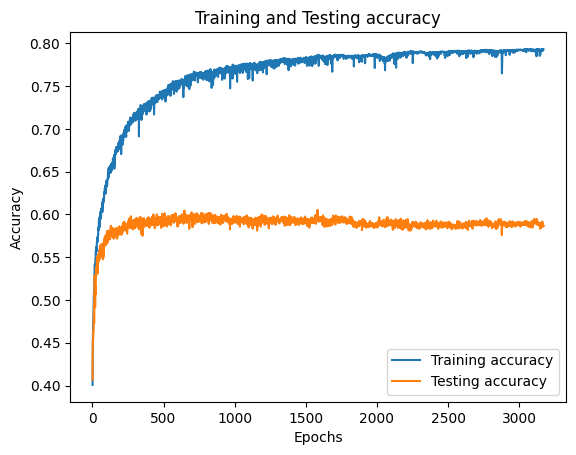

In [52]:
layers = np.array([input_dim, 8, 4, output_dim], dtype=np.int32)
num_layers = len(layers)

mlp = lib.create_MyMLP(layers, num_layers, seed)

lib.summary_MyMLP(mlp)

alpha = 0.01
epochs = 10000
is_classification = True

lib.train_MyMLP(
    mlp,
    X_train_flat,
    y_train,
    X_test_flat,
    y_test,
    X_train_flat.shape[0],
    X_test_flat.shape[0],
    X_train_flat.shape[1],
    y_train.shape[1],
    alpha,
    epochs,
    is_classification
)

path = '../PA_models/MLP_models/lr001_6912_8_4_3/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

Bon, le bruit dans les données rend de plus en plus difficile l'analyse des courbes. Pour remédier à ce problème, nous avons décidé d'utiliser la technique de la moving average vue en cours afin de lisser les courbes. La moving average est une méthode statistique qui permet de réduire les fluctuations et de faire ressortir les tendances sous-jacentes. En calculant la moyenne des valeurs sur une fenêtre glissante de taille définie, nous obtenons des courbes plus stables et plus faciles à interpréter. Cela nous aidera à mieux visualiser les performances réelles du modèle sans être perturbés par les variations erratiques des données brute

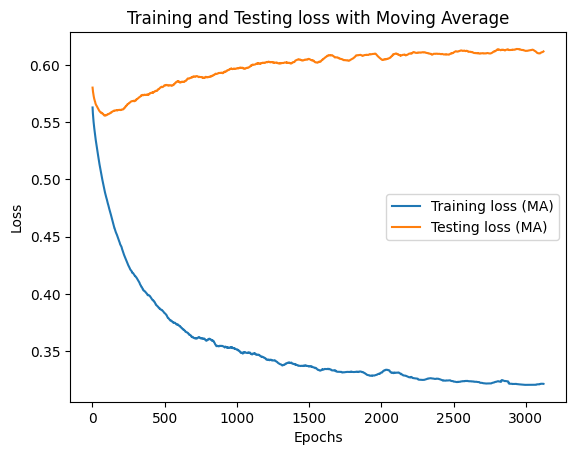

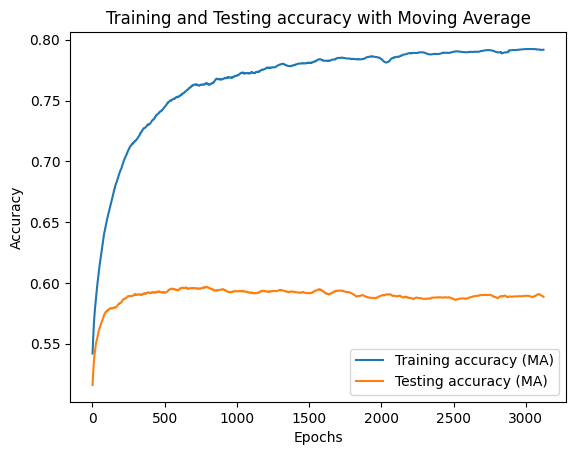

In [53]:
plot_losses_moving_average(train_losses, test_losses, 50)
plot_accuracies_moving_average(train_accuracies, test_accuracies, 50)

In [54]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.61


On constate que l'ajout de cette couche a amélioré les performances du modèle, aussi bien sur les données d'entraînement que sur celles de test, avec une augmentation d'environ 2%, mais nous remarquons toujours de l'overfitting.

Essayons maintenant d'augmenter le nombre de neurones dans la première couche :

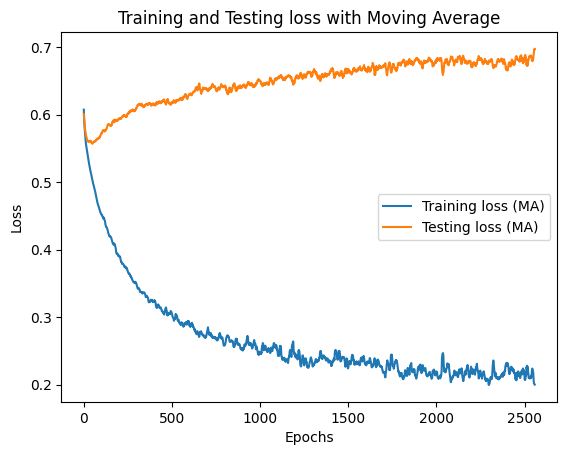

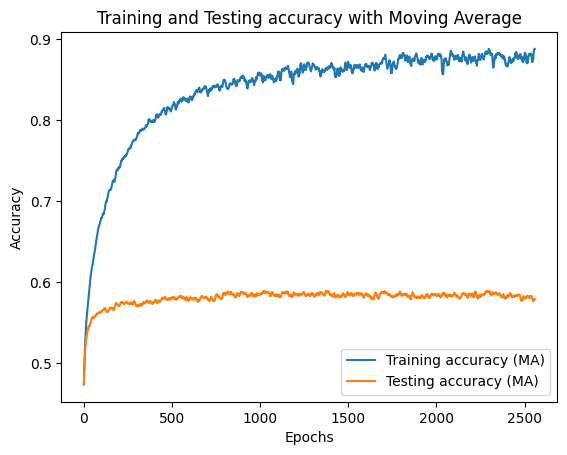

In [48]:
layers = np.array([input_dim, 16, 4, output_dim], dtype=np.int32)
num_layers = len(layers)

mlp = lib.create_MyMLP(layers, num_layers, seed)

lib.summary_MyMLP(mlp)

alpha = 0.01
epochs = 10000
is_classification = True

lib.train_MyMLP(
    mlp,
    X_train_flat,
    y_train,
    X_test_flat,
    y_test,
    X_train_flat.shape[0],
    X_test_flat.shape[0],
    X_train_flat.shape[1],
    y_train.shape[1],
    alpha,
    epochs,
    is_classification
)

path = '../PA_models/MLP_models/lr001_6912_16_4_3/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses_moving_average(train_losses, test_losses, 10)
plot_accuracies_moving_average(train_accuracies, test_accuracies, 10)

In [49]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.60


Nous constatons que la moyennes des accuracys stagne toujours vers 0.56, donc le modèle ne performe pas mieux mais on constate que l'effet d'overfitting est accentué.

Essayons plutôt d'ajouter une autre petite couche suplémentaire à 4 neurones.

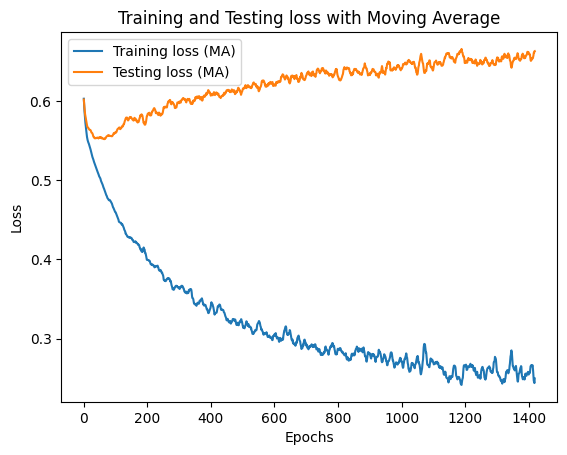

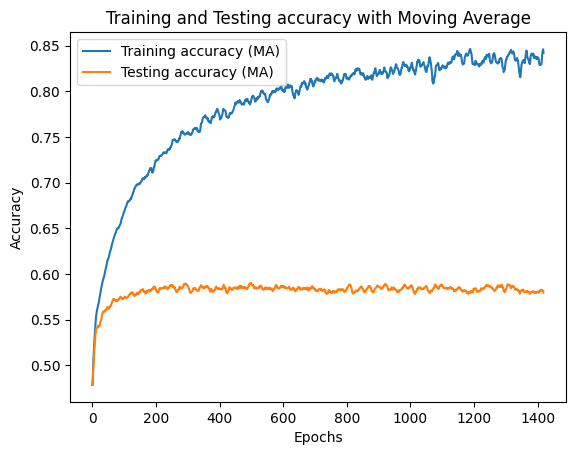

In [46]:
layers = np.array([input_dim, 8, 4, 4, output_dim], dtype=np.int32)
num_layers = len(layers)

mlp = lib.create_MyMLP(layers, num_layers, seed)

lib.summary_MyMLP(mlp)

alpha = 0.01
epochs = 10000
is_classification = True

lib.train_MyMLP(
    mlp,
    X_train_flat,
    y_train,
    X_test_flat,
    y_test,
    X_train_flat.shape[0],
    X_test_flat.shape[0],
    X_train_flat.shape[1],
    y_train.shape[1],
    alpha,
    epochs,
    is_classification
)

path = '../PA_models/MLP_models/lr001_6912_16_4_4_3/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses_moving_average(train_losses, test_losses, 10)
plot_accuracies_moving_average(train_accuracies, test_accuracies, 10)

In [45]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.60


De la même manière que l'ajout de neurones dans la première couche, l'ajout d'une nouvelle couche ne semble pas améliorer les performances du modèle. Au contraire, cela accentue l'effet de surapprentissage (overfitting).

Nous remarquons, d'après ces résultats, que l'ajout d'une couche améliore l'accuracy, mais accentue très rapidement l'effet de
 overfitting. Notre première explication de ce phénomène est que le learning rate pourrait être un peu trop élevé.

## CNN

In [57]:
# Charger le dataset
image_size = 48  # Taille des images
dataset_path = '../dataset_upgrade'
X_train, y_train, X_test, y_test = load_dataset(dataset_path, image_size)
X_train, y_train = shuffle_dataset(X_train, y_train)

X_test, y_test = shuffle_dataset(X_test, y_test)
X_train, X_test = X_train/255., X_test/255.

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print(X_train[:10])


input_shape = X_train[0].shape 

X_train_flat = X_train.flatten()
X_test_flat = X_test.flatten()

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

X_train shape: (14763, 48, 48, 3)
y_train shape: (14763, 3)
X_test shape: (3700, 48, 48, 3)
y_test shape: (3700, 3)
[[[[0.5254902  0.63529412 0.69019608]
   [0.52941176 0.63921569 0.69411765]
   [0.53333333 0.64313725 0.69803922]
   ...
   [0.56078431 0.64705882 0.70196078]
   [0.56078431 0.64705882 0.70196078]
   [0.56078431 0.64705882 0.70196078]]

  [[0.53333333 0.64313725 0.69803922]
   [0.5372549  0.64705882 0.70196078]
   [0.54117647 0.65098039 0.70588235]
   ...
   [0.56470588 0.65490196 0.70980392]
   [0.56078431 0.64705882 0.70196078]
   [0.56078431 0.64705882 0.70196078]]

  [[0.53333333 0.64313725 0.69803922]
   [0.5372549  0.64705882 0.70196078]
   [0.54117647 0.65098039 0.70588235]
   ...
   [0.55686275 0.65882353 0.70980392]
   [0.55686275 0.64313725 0.69803922]
   [0.55686275 0.64313725 0.69803922]]

  ...

  [[0.9254902  0.92941176 0.94901961]
   [0.87058824 0.8745098  0.89411765]
   [0.88627451 0.89019608 0.90980392]
   ...
   [0.79607843 0.79607843 0.82745098]
   [0.8

Nous allons maintenant tester le CNN sur notre dataset. Le CNN, étant essentiellement un MLP précédé de couches de convolution et de pooling, nous permet de répéter les tests effectués avec le MLP en y ajoutant la convolution. Comme pour le MLP, chaque sortie de couches cachées se voit appliquer une fonction non linéaire, et nous avons décidé de conserver la fonction tanh.

Reprenons notre premier modèle (une seule couche cachée de 8 neurones) et faisons-le précéder par une simple couche de convolution de 8 kernels, suivie d'une couche de maxpooling, avec un learning rate de 0.01.

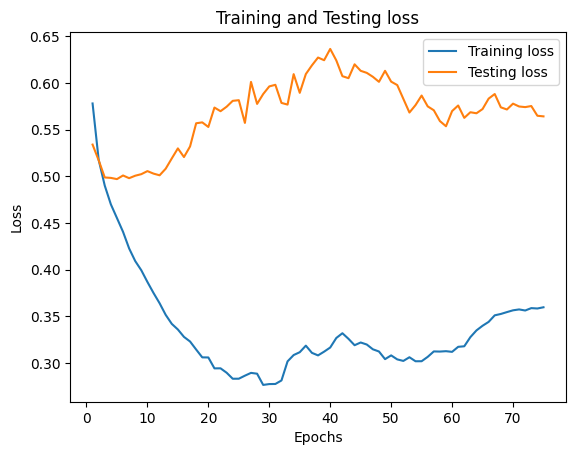

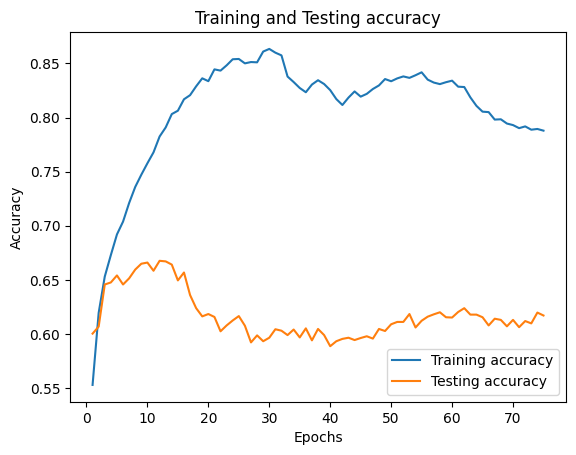

In [42]:
input_shape = X_train[0].shape 

X_train_flat = X_train.flatten()
X_test_flat = X_test.flatten()

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

model = my_lib.create_MyCNN(input_shape[0], input_shape[1], input_shape[2])

my_lib.add_conv_layer_MyCNN(model, 8, 3, 1, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_maxpooling_layer_MyCNN(model, 2)

my_lib.add_dense_layer_MyCNN(model, 8, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_dense_layer_MyCNN(model, 3, "Tanh".encode('utf-8'), 0.0, seed)

my_lib.set_optimizer_SGD(model, 0.01)

epochs = 100000
batch_size = 1
my_lib.train_MyCNN(
                model,
                X_train_flat, y_train_flat,
                X_test_flat, y_test_flat,
                X_train.shape[0],
                X_test.shape[0],  
                input_shape[0], input_shape[1], input_shape[2],
                y_train.shape[1],
                epochs,
                batch_size,
                seed
            )

my_lib.destroy_MyCNN(model)

path = '/home/bao/GranolaGPT/PA_models/CNN_models/8C_8D_3D_batch1/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [43]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.67


Nous remarquons que l'effet de surapprentissage est toujours présent. Cela dit, nous constatons également qu'une simple couche de convolution précédant notre architecture MLP la plus simple permet d'atteindre une précision de 0,67 sur le test, dépassant ainsi notre meilleure architecture MLP actuelle.

Essayons maintenant de rajouter des kernels à la couche de convolution :

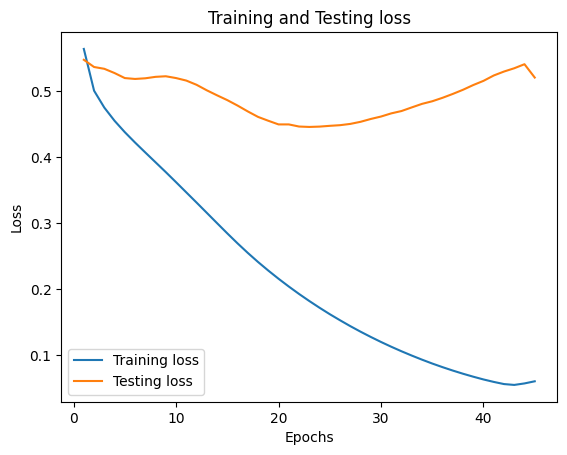

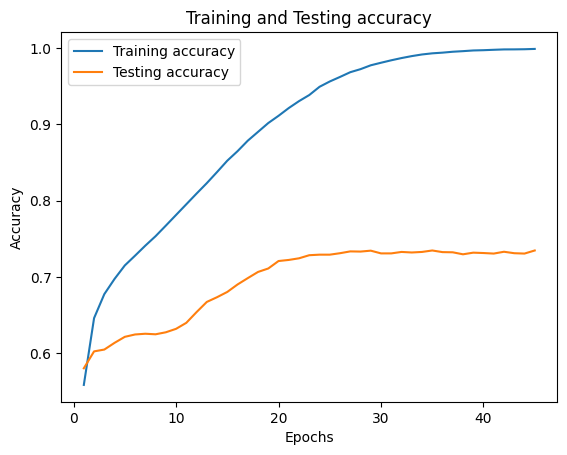

In [58]:
path = '/home/bao/GranolaGPT/PA_models/CNN_models/16C_32D_3D/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [59]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.73


On constate qu'en augmentant le nombre de kernels, l'accuracy sur les données de test s'améliore considérablement, atteignant 0,73. Cependant, on remarque également que l'effet de surapprentissage devient beaucoup plus prononcé.

Dans cette lancée, nous nous sommes naturellement demandés jusqu'ou l'on pouvait augmenter le nombre de kernels sur une seule couchde convolution.

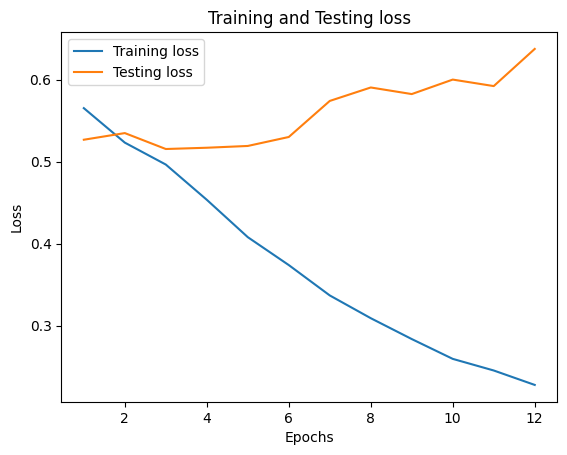

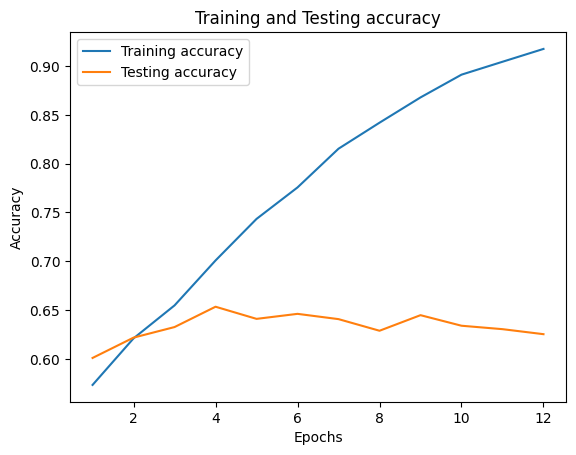

In [60]:
path = '/home/bao/GranolaGPT/PA_models/CNN_models/32C_32D_3D/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [61]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.65


En doublant le nombre de kernels dans la couche de convolution, nous constatons, sans grande surprise, que le modèle surapprend très rapidement. L'accuracy sur les données de test diminue également, passant de 0,73 à 0,65.

Avec un learning rate de 0.01, nous pouvons conclure qu'il n'est pas utile d'aller au delà de 32 kernels dans une couche de convolution.

Nous allons maintenant tester une autre architecture de MLP, déjà évaluée dans la section précédente, en y ajoutant une couche de convolution :

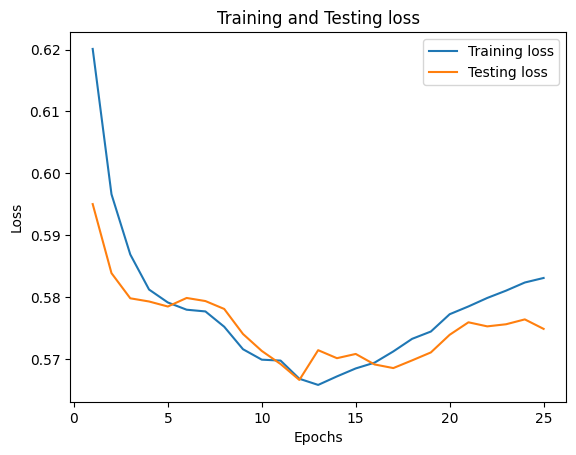

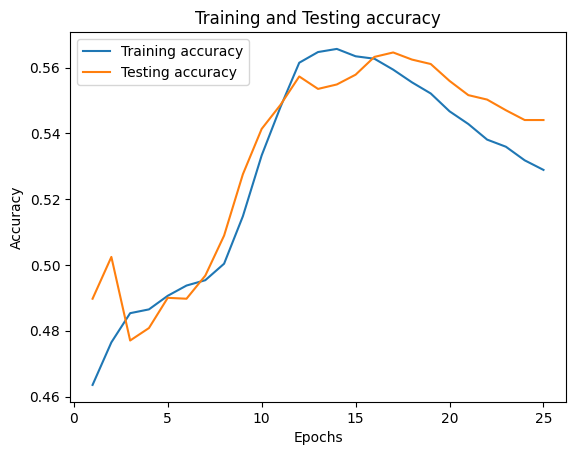

In [64]:
input_shape = X_train[0].shape 

X_train_flat = X_train.flatten()
X_test_flat = X_test.flatten()

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

model = my_lib.create_MyCNN(input_shape[0], input_shape[1], input_shape[2])

my_lib.add_conv_layer_MyCNN(model, 32, 3, 1, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_maxpooling_layer_MyCNN(model, 2)

my_lib.add_dense_layer_MyCNN(model, 32, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_dense_layer_MyCNN(model, 3, "Tanh".encode('utf-8'), 0.0, seed)

my_lib.set_optimizer_SGD(model, 0.01)

epochs = 100000
batch_size = 1
my_lib.train_MyCNN(
                model,
                X_train_flat, y_train_flat,
                X_test_flat, y_test_flat,
                X_train.shape[0],
                X_test.shape[0],  
                input_shape[0], input_shape[1], input_shape[2],
                y_train.shape[1],
                epochs,
                batch_size,
                seed
            )

my_lib.destroy_MyCNN(model)

path = '/home/bao/GranolaGPT/PA_models/CNN_models/32C_8D_4D_3D/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [65]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.56


Au vu des résultats précédents, comme pour le MLP, nous sommes encouragés à réduire le learning rate afin d'éviter cet overfitting instantané.

Reprenons l'entraînement avec notre meilleur architecture actuelle avec un learning rate plus petit :

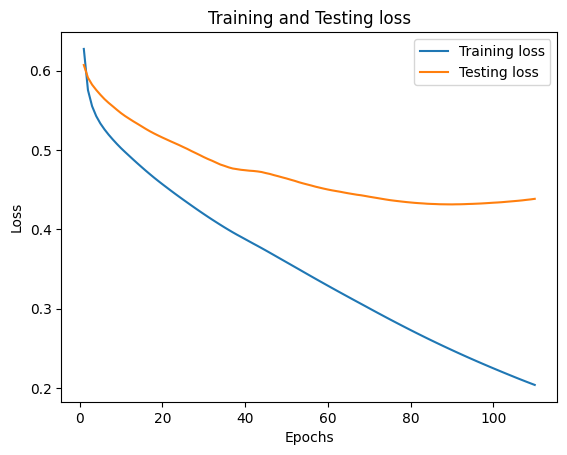

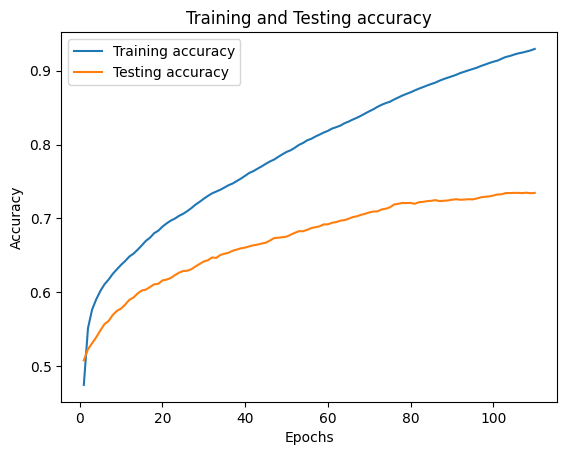

In [66]:
input_shape = X_train[0].shape 

X_train_flat = X_train.flatten()
X_test_flat = X_test.flatten()

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

model = my_lib.create_MyCNN(input_shape[0], input_shape[1], input_shape[2])

my_lib.add_conv_layer_MyCNN(model, 16, 3, 1, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_maxpooling_layer_MyCNN(model, 2)

my_lib.add_dense_layer_MyCNN(model, 32, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_dense_layer_MyCNN(model, 3, "Tanh".encode('utf-8'), 0.0, seed)

my_lib.set_optimizer_SGD(model, 0.001)

epochs = 100000
batch_size = 1
my_lib.train_MyCNN(
                model,
                X_train_flat, y_train_flat,
                X_test_flat, y_test_flat,
                X_train.shape[0],
                X_test.shape[0],  
                input_shape[0], input_shape[1], input_shape[2],
                y_train.shape[1],
                epochs,
                batch_size,
                seed
            )

my_lib.destroy_MyCNN(model)

path = '/home/bao/GranolaGPT/PA_models/CNN_models/16C_32D_lr_0_001/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [67]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.73


Nous observons des courbes beaucoup plus stables, avec un effet de surapprentissage nettement réduit, et le modèle converge encore vers notre meilleur accuracy (0.73).

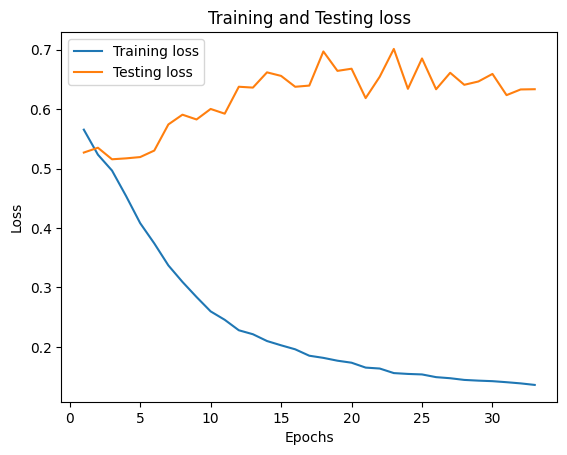

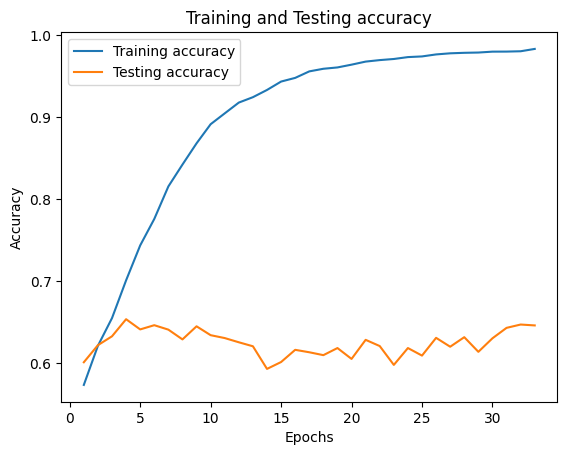

In [68]:
input_shape = X_train[0].shape 

X_train_flat = X_train.flatten()
X_test_flat = X_test.flatten()

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

model = my_lib.create_MyCNN(input_shape[0], input_shape[1], input_shape[2])

my_lib.add_conv_layer_MyCNN(model, 32, 3, 1, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_maxpooling_layer_MyCNN(model, 2)

my_lib.add_dense_layer_MyCNN(model, 32, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_dense_layer_MyCNN(model, 3, "Tanh".encode('utf-8'), 0.0, seed)

my_lib.set_optimizer_SGD(model, 0.001)

epochs = 100000
batch_size = 1
my_lib.train_MyCNN(
                model,
                X_train_flat, y_train_flat,
                X_test_flat, y_test_flat,
                X_train.shape[0],
                X_test.shape[0],  
                input_shape[0], input_shape[1], input_shape[2],
                y_train.shape[1],
                epochs,
                batch_size,
                seed
            )

my_lib.destroy_MyCNN(model)

path = '/home/bao/GranolaGPT/PA_models/CNN_models/32C_32C_3D_lr_001/metrics.json'

history = load_json(path)

train_losses = history["train_losses"]
test_losses = history["test_losses"]

train_accuracies = history["train_accuracies"]
test_accuracies = history["test_accuracies"]

plot_losses(train_losses, test_losses)
plot_accuracies(train_accuracies, test_accuracies)

In [69]:
max_test_accuray = max(test_accuracies)
print(f"Max accuracy sur les donées test : {max_test_accuray:.2f}")

Max accuracy sur les donées test : 0.65


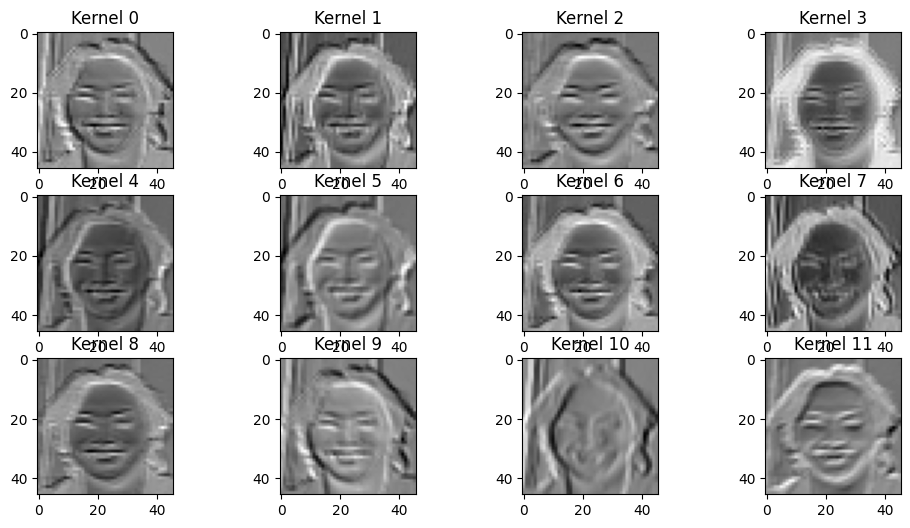

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Charger les outputs depuis les fichiers
outputs = [np.loadtxt(f"../conv_output/output_kernel_{i}.txt") for i in range(15)]

# Visualiser les outputs
fig, axes = plt.subplots(3, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(outputs[i], cmap='gray')
    ax.set_title(f"Kernel {i}")
plt.show()